# Notebook 2: Deskriptive Statistik und Verteilungsdiagnostik

**Statistik für Data Science** · Kurs 3,906 · Bachelor Computer Science · HS2026
Universität St. Gallen

---
### Projektteam:
- Andrin Greitmann
- Noah Appenzeller
- Manuel Schmid

---

Dieses Notebook führt die Inhalte von **VL02 (Deskriptive Statistik und Verteilungsdiagnostik)** in Python aus. 

## 0. Setup
Importiert `pandas`, `numpy`, `seaborn` und `matplotlib` und setzt den Seed.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seed: Startwert für den Zufallsgenerator. Gleicher Seed bei jedem Durchlauf damit Resultate deterministisch & reproduzierbar sind. 
# Den Wert selbst haben wir beliebig gewählt, wir haben ihn als erstes vor der Analyse gewählt und danach nicht mehr geändert.
# Der Seed wird für alles Zufällige in allen Notebooks verwendet.
SEED = 2001
RNG = np.random.default_rng(SEED)

# Plot-Defauls
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7.5, 4.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [6]:
import sys

print("Python  ", sys.version.split()[0])
for modul in (np, pd, sns):
    print(f"{modul.__name__:8s}", modul.__version__)
print("Seed    ", SEED)

Python   3.14.4
numpy    2.5.3
pandas   3.0.6
seaborn  0.13.2
Seed     2001


### Unseren Datensatz laden

In [ ]:
from ucimlrepo import fetch_ucirepo

# Datensatz direkt aus dem UCI Repository laden (ID 117 = Census-Income KDD)
census_income_kdd = fetch_ucirepo(id=117)

# Etwas spezielles an unserem Datenset: ucimlrepo liefert die Daten aufgeteilt in Features und Target. 
# (Wahrscheinlich für Machine Learning Projekte/Algorithmen)
# Target ist das Einkommen (über/unter 50K), Features sind alle anderen Merkmale.
X = census_income_kdd.data.features
y = census_income_kdd.data.targets

# Für die EDA wollten wir alle Spalten in einem DataFrame damit das Einkommen mit den anderen Merkmalen verglichen werden kann.
# join() funktioniert hier zum Glück recht einfach, weil X und y dieselben Zeilen in derselben Reihenfolge haben.
census = X.join(y)
 
# Leerzeichen bei den Textspalten entfernen
text_spalten = census.select_dtypes(exclude="number").columns
census[text_spalten] = census[text_spalten].apply(lambda s: s.str.strip())

# Wir wollen die Spalten umbenennen, sodass es ersichtlicher ist, mit was wir arbeiten
# Dies ist jedoch in den Metadaten der folgenden Ausgabe noch nicht ersichtlich, erst bei allen späteren Ausgaben.

spalten_umbenennung = {
    "AAGE": "AGE", "ACLSWKR": "CLASS_OF_WORKER", "ADTINK": "INDUSTRY_CODE",      
    "ADTOCC": "OCCUPATION_CODE", "AHGA": "EDUCATION", "AHSCOL": "ENROLLED_IN_EDU",
    "AMARITL": "MARITAL_STATUS", "AMJIND": "MAJOR_INDUSTRY", "AMJOCC": "MAJOR_OCCUPATION",
    "ARACE": "RACE", "AREORGN": "HISPANIC_ORIGIN", "ASEX": "SEX",
    "AUNMEM": "LABOR_UNION_MEMBER", "AUNTYPE": "UNEMPLOYMENT_REASON", "AWKSTAT": "EMPLOYMENT_STATUS",
    "CAPGAIN": "CAPITAL_GAINS", "GAPLOSS": "CAPITAL_LOSSES", "DIVVAL": "DIVIDENDS",
    "FILESTAT": "TAX_FILER_STATUS", "GRINREG": "PREV_REGION", "GRINST": "PREV_STATE",
    "HHDFMX": "HOUSEHOLD_STAT_DETAILED", "HHDREL": "HOUSEHOLD_SUMMARY", "MARSUPWRT": "WEIGHT",
    "MIGMTR1": "MIGRATION_MSA", "MIGMTR3": "MIGRATION_REG", "MIGMTR4": "MIGRATION_WITHIN_REG",
    "MIGSAME": "SAME_HOUSE_1YR", "MIGSUN": "MIGRATION_SUNBELT", "NOEMP": "NUM_EMPLOYEES",
    "PARENT": "PARENTS_PRESENT", "PEFNTVTY": "BIRTH_COUNTRY_FATHER", "PEMNTVTY": "BIRTH_COUNTRY_MOTHER",
    "PENATVTY": "BIRTH_COUNTRY_SELF", "PRCITSHP": "CITIZENSHIP", "SEOTR": "SELF_EMPLOYED",
    "VETQVA": "VET_QUESTIONNAIRE", "VETYN": "VETERANS_BENEFITS", "WKSWORK": "WEEKS_WORKED",
    "AHRSPAY": "WAGE_PER_HOUR", "year": "YEAR", "income": "INCOME"
}
census = census.rename(columns=spalten_umbenennung)

# Metadaten: Herkunft, Beschreibung und Erhebung des Datensatzes (Damit wir auf Bias analysieren können)
print("Metadata: " + str(census_income_kdd.metadata))

print(f"Rows: {census.shape[0]}, Columns: {census.shape[1]}")

# Variablenbeschreibung: Name, Typ und Bedeutung jeder Spalte (Grundlage um später Messniveau zu bestimmen)
print("Variable descriptions:")

# display(census_income_kdd.variables)

Metadata: {'uci_id': 117, 'name': 'Census-Income (KDD)', 'repository_url': 'https://archive.ics.uci.edu/dataset/117/census+income+kdd', 'data_url': 'https://archive.ics.uci.edu/static/public/117/data.csv', 'abstract': 'This data set contains weighted census data extracted from the 1994 and 1995 current population surveys conducted by the U.S. Census Bureau.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 299285, 'num_features': 41, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Education Level', 'Marital Status', 'Race', 'Sex', 'Other', 'Nationality', 'Income'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5N30T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set contains weighted census data extracted

### Datensatz bereinigen
Hier wenden wir die Bereinigung aus NB01 (Abschnitt 5) an, inklusive der neuen Spalten aus den originalen CPS-Daten (NB01, 5.1). Danach ist `census` der bereinigte Datensatz, die Rohdaten bleiben als `census_raw` verfügbar.

In [ ]:
# Die Abfrage sorgt dafür, dass ein zweites Ausführen dieser Zelle wieder
# bei den Rohdaten startet (sonst würde z.B. der Stundenlohn ein zweites Mal durch 100 geteilt).
if "census_raw" not in globals():
    census_raw = census
census = census_raw.copy()

# 1) Migrationsblock 1995 wurde nicht erhoben, auch wo "Not in universe" steht (3.2)
jahr_95 = census["YEAR"] == 95
census.loc[jahr_95, ["SAME_HOUSE_1YR", "PREV_REGION"]] = np.nan

# 2) Die Bundesstaaten passen nicht zur Region, die Spalte verwenden wir nicht (3.3)
census = census.drop(columns="PREV_STATE")

# 3) Stundenlohn: 0 bei Erwerbstätigen heisst "nicht erfasst" (3.2), die Einheit ist Cents (4.2)
nicht_erfasst = (census["WEEKS_WORKED"] > 0) & (census["WAGE_PER_HOUR"] == 0)
census["WAGE_PER_HOUR"] = census["WAGE_PER_HOUR"].astype(float).where(~nicht_erfasst) / 100

# 4) Antwortausfall bei der hispanischen Herkunft (3.2)
census["HISPANIC_ORIGIN"] = census["HISPANIC_ORIGIN"].replace({"Do not know": np.nan, "NA": np.nan})

# 5) Geburtsländer nicht imputieren, sondern als eigene Kategorie führen (3.4 und 3.7)
census["BIRTH_COUNTRY_SELF"] = census["BIRTH_COUNTRY_SELF"].fillna("Foreign, Unknown")
eltern = ["BIRTH_COUNTRY_FATHER", "BIRTH_COUNTRY_MOTHER"]
census[eltern] = census[eltern].fillna("Unknown")

# 6) Messniveau im Datentyp festhalten, damit pandas keine unzulässigen Mittelwerte rechnet (1 und 4)
BILDUNG = [
    "Children",
    "Less than 1st grade",
    "1st 2nd 3rd or 4th grade",
    "5th or 6th grade",
    "7th and 8th grade",
    "9th grade",
    "10th grade",
    "11th grade",
    "12th grade no diploma",
    "High school graduate",
    "Some college but no degree",
    "Associates degree-occup /vocational",
    "Associates degree-academic program",
    "Bachelors degree(BA AB BS)",
    "Masters degree(MA MS MEng MEd MSW MBA)",
    "Prof school degree (MD DDS DVM LLB JD)",
    "Doctorate degree(PhD EdD)",
]
census["EDUCATION"] = census["EDUCATION"].astype(pd.CategoricalDtype(BILDUNG, ordered=True))
# NUM_EMPLOYEES sind Grössenklassen 0 bis 6, also ordinal und keine Anzahl (4.1)
census["NUM_EMPLOYEES"] = census["NUM_EMPLOYEES"].astype(pd.CategoricalDtype(list(range(7)), ordered=True))
# Nominale Codes, die als Zahl gespeichert sind (1 und 4.1)
nominale_codes = ["INDUSTRY_CODE", "OCCUPATION_CODE", "SELF_EMPLOYED", "VETERANS_BENEFITS"]
census[nominale_codes] = census[nominale_codes].astype("category")

# 7) Neue Spalten aus den originalen CPS-Dateien: exaktes Einkommen, Arbeitsstunden, Wohnort usw. (NB01, 5.1)
zusatz = pd.read_csv("../zusatzdaten/census_zusatz.csv.gz", index_col="ROW")
# Kontrolle: Die Zusatzdaten müssen Zeile für Zeile zu census passen
assert (zusatz["CHECK_AGE"].to_numpy() == census["AGE"].to_numpy()).all(), "Zusatzdaten passen nicht zu census"
assert np.allclose(zusatz["CHECK_WEIGHT"].to_numpy(), census["WEIGHT"].to_numpy()), "Zusatzdaten passen nicht zu census"
census = census.join(zusatz.drop(columns=["CHECK_AGE", "CHECK_WEIGHT"]))
ARMUT = ["Below poverty line", "100-124% of poverty line", "125-149% of poverty line", "150%+ of poverty line"]
census["POVERTY_LEVEL"] = census["POVERTY_LEVEL"].astype(pd.CategoricalDtype(ARMUT, ordered=True))

# Kontrolle: Eine Bildungskategorie, die nicht in BILDUNG steht, würde still zu NaN werden
assert census["EDUCATION"].notna().all(), "Unbekannte Kategorie in EDUCATION"

print(f"census (bereinigt): {census.shape[0]} Zeilen, {census.shape[1]} Spalten")
print(f"census_raw:         {census_raw.shape[0]} Zeilen, {census_raw.shape[1]} Spalten\n")
fehlend = census.isna().sum()
print("Fehlende Werte nach der Bereinigung:")
print(fehlend[fehlend > 0].sort_values(ascending=False))

---

## 1. Diverse Plots

In diesem Abschnitt schauen wir uns den bereinigten Datensatz mit zehn verschiedenen Plots an. Die Plots bauen aufeinander auf und erzählen zusammen eine Geschichte, die wir später für die Präsentation verwenden können:

> **Wer verdient in den USA (1994/95) über 50'000 USD im Jahr?**

| # | Frage | Plot-Art |
|---|---|---|
| 1 | Wer ist im Datensatz? | Bevölkerungspyramide (Histogramm) |
| 2 | Wie hängt ein Einkommen über 50k von Alter und Geschlecht ab? | Liniendiagramm |
| 3 | Wie stark zählt die Bildung? | Balkendiagramm |
| 4 | Muss man dafür das ganze Jahr arbeiten? | Überlagerte Histogramme (Modalität) |
| 5 | Liegt der Unterschied zwischen Frauen und Männern nur am Beruf? | Scatterplot |
| 6 | Wie ist der Stundenlohn verteilt? | Histogramm mit Mittelwert und Median |
| 7 | Verdienen Männer auch pro Stunde mehr? | ECDF |
| 8 | Wie verändert Bildung Höhe und Streuung des Lohns? | Boxplot |
| 9 | Verdienen Gewerkschaftsmitglieder mehr? | Stripplot |
| 10 | Und das Vermögen? | Histogramm auf log-Skala (Heavy Tail) |

**Was für alle Plots gilt:**
- Anteile, Histogramme und ECDF sind mit `WEIGHT` gewichtet und beschreiben damit die Bevölkerung (siehe NB01, Abschnitt 2). Box- und Stripplots kann seaborn nicht gewichten, sie beschreiben die Stichprobe.
- `INCOME` ist das gesamte Jahreseinkommen einer Person. Für Einkommensfragen nehmen wir nur Personen ab 15 Jahren, weil die Einkommensfragen erst ab 15 gestellt werden (NB01, Abschnitt 2). Bei der Bildung nehmen wir Personen ab 25, weil die Ausbildung bei Jüngeren oft noch läuft.
- Den Stundenlohn gibt es nur für Personen, die im Stundenlohn bezahlt werden (NB01, Abschnitt 3.2). Die Plots 6 bis 9 beschreiben nur diese Gruppe, nicht alle Erwerbstätigen.
- Jede Gruppe hat in allen Plots dieselbe Farbe: Frauen orange, Männer blau, über 50k violett, unter 50k grau.

In [9]:
# Farben: jede Gruppe hat in allen Plots dieselbe Farbe
FARBE_FRAUEN = "#eb6834"
FARBE_MAENNER = "#2a78d6"
FARBE_UEBER_50K = "#4a3aa7"
FARBE_UNTER_50K = "#85837c"
FARBEN_GESCHLECHT = {"Frauen": FARBE_FRAUEN, "Männer": FARBE_MAENNER}
FARBEN_EINKOMMEN = {"unter 50k": FARBE_UNTER_50K, "50k und mehr": FARBE_UEBER_50K}

# Hilfsspalten nur für die Plots, census selbst bleibt unverändert
daten = census.assign(
    UEBER_50K=census["INCOME"] == "50000+.",
    GESCHLECHT=census["SEX"].map({"Female": "Frauen", "Male": "Männer"}),
)
daten["EINKOMMEN"] = daten["UEBER_50K"].map({True: "50k und mehr", False: "unter 50k"})
ab15 = daten[daten["AGE"] >= 15]


def anteil_ueber_50k(df: pd.DataFrame, gruppen) -> pd.DataFrame:
    """Gewichteter Anteil (in %) der Personen mit über 50k je Gruppe, dazu die Anzahl Zeilen n."""
    g = df.groupby(gruppen, observed=True)
    return pd.DataFrame(
        {
            "n": g.size(),
            "anteil_%": g.apply(lambda d: np.average(d["UEBER_50K"], weights=d["WEIGHT"]) * 100),
        }
    )


def gewichtetes_quantil(werte: pd.Series, gewichte: pd.Series, p: float) -> float:
    """Quantil Q(p) wie in VL02, nur zählt jede Person mit ihrem Gewicht."""
    reihenfolge = np.argsort(werte.to_numpy())
    werte_sortiert = werte.to_numpy()[reihenfolge]
    anteil_kumuliert = np.cumsum(gewichte.to_numpy()[reihenfolge]) / gewichte.sum()
    return werte_sortiert[np.searchsorted(anteil_kumuliert, p)]


print(f"Alle Personen: {len(daten)}, davon ab 15 Jahren: {len(ab15)}")
print(f"Anteil über 50k ab 15 Jahren (gewichtet): {np.average(ab15['UEBER_50K'], weights=ab15['WEIGHT']):.1%}")

Alle Personen: 199523, davon ab 15 Jahren: 152101
Anteil über 50k ab 15 Jahren (gewichtet): 8.3%


### 1.1 Wer ist im Datensatz? Die Bevölkerungspyramide

Bevor wir über Einkommen sprechen, schauen wir, wen der Datensatz überhaupt abbildet. Die Bevölkerungspyramide ist ein Histogramm des Alters, getrennt nach Geschlecht und um 90 Grad gedreht: links die Männer, rechts die Frauen, ein Balken pro Altersjahr.

Bevölkerungspyramide: alle 199523 Zeilen, gewichtet.


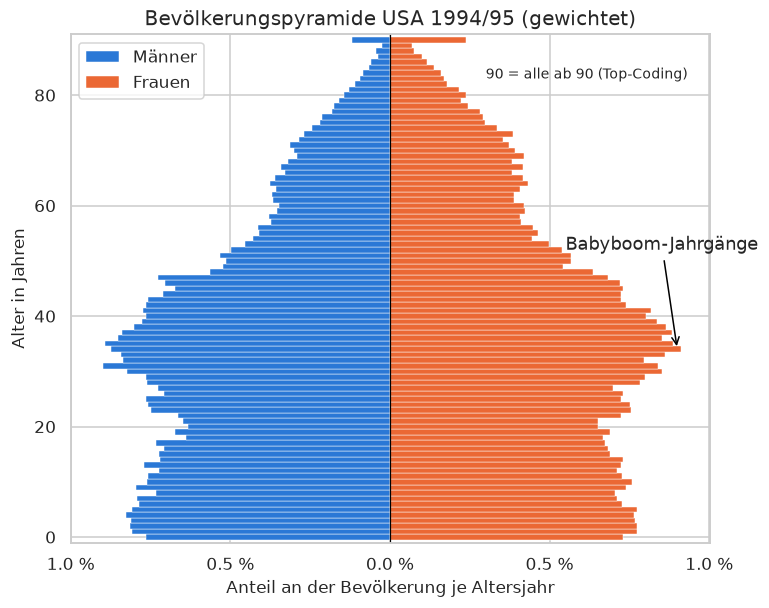

Anteil unter 15 Jahren:       22.8%
Frauenanteil ab 75 Jahren:    62.2%
Breitestes Altersjahr (beide): 34 Jahre


In [10]:
# Gewichteter Anteil an der Bevölkerung je Altersjahr und Geschlecht, in %
pyramide = daten.groupby(["AGE", "GESCHLECHT"])["WEIGHT"].sum().unstack() / daten["WEIGHT"].sum() * 100
print(f"Bevölkerungspyramide: alle {len(daten)} Zeilen, gewichtet.")

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(pyramide.index, -pyramide["Männer"], height=1.0, color=FARBE_MAENNER, edgecolor="white", linewidth=0.3, label="Männer")
ax.barh(pyramide.index, pyramide["Frauen"], height=1.0, color=FARBE_FRAUEN, edgecolor="white", linewidth=0.3, label="Frauen")
ax.axvline(0, color="black", linewidth=0.8)

# Links sollen auch positive Prozente stehen, deshalb die Beschriftung selbst setzen
ticks = np.arange(-1.0, 1.01, 0.5)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{abs(t):.1f} %" for t in ticks])
ax.set_ylim(-1, 91)

ax.annotate("Babyboom-Jahrgänge", xy=(0.9, 34), xytext=(0.55, 52), arrowprops={"arrowstyle": "->", "color": "black"})
ax.annotate("90 = alle ab 90 (Top-Coding)", xy=(0.25, 90), xytext=(0.3, 83), fontsize=9)
ax.set_title("Bevölkerungspyramide USA 1994/95 (gewichtet)")
ax.set_xlabel("Anteil an der Bevölkerung je Altersjahr")
ax.set_ylabel("Alter in Jahren")
ax.legend(loc="upper left")
plt.show()

alt = daten[daten["AGE"] >= 75]
print(f"Anteil unter 15 Jahren:       {np.average(daten['AGE'] < 15, weights=daten['WEIGHT']):.1%}")
print(f"Frauenanteil ab 75 Jahren:    {np.average(alt['GESCHLECHT'] == 'Frauen', weights=alt['WEIGHT']):.1%}")
print(f"Breitestes Altersjahr (beide): {pyramide.sum(axis=1).idxmax()} Jahre")

**Erkenntnis:**
- Die Pyramide ist eher eine Zwiebel: Am breitesten ist sie zwischen 30 und 40 Jahren, am meisten Personen sind 34. Das sind die späten **Babyboom-Jahrgänge** (geboren um 1960). Darunter liegt eine Delle bei 18 bis 22 Jahren, die zu den geburtenschwachen Jahrgängen der 1970er passt.
- Ab etwa 65 Jahren gibt es deutlich **mehr Frauen** als Männer, ab 75 Jahren sind über 60 % der Personen Frauen. Das passt zur höheren Lebenserwartung von Frauen.
- Der Balken bei 90 ist breiter als der bei 89. Das ist das **Top-Coding** aus NB01: Alle älteren Personen stehen als 90 im Datensatz.
- Gut ein Fünftel der Bevölkerung ist jünger als 15. Für diese Personen gibt es keine Einkommensfragen, deshalb nehmen wir ab jetzt bei Einkommensfragen nur Personen ab 15.

### 1.2 Alter und Geschlecht: Wer liegt über 50k?

Insgesamt liegen nur rund 8 % der Personen ab 15 über 50k. Wie verändert sich dieser Anteil mit dem Alter, und gibt es einen Unterschied zwischen Frauen und Männern? Wir rechnen den gewichteten Anteil für jedes Altersjahr von 15 bis 85 (darüber werden die Gruppen klein).

Linien: Personen von 15 bis 85 Jahren, 150291 Zeilen, pro Altersjahr und Geschlecht 126 bis 1824 Personen.


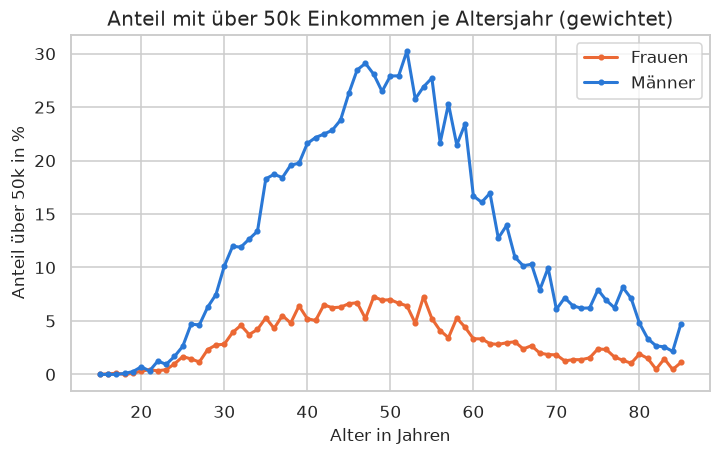

Frauen: Maximum 7.3 % mit 54 Jahren
Männer: Maximum 30.3 % mit 52 Jahren

Ausgewählte Altersjahre (in %):
GESCHLECHT  Frauen  Männer
AGE                       
25             1.7     2.6
30             2.8    10.1
40             5.2    21.6
50             7.0    27.9
60             3.3    16.7


In [11]:
nach_alter = anteil_ueber_50k(ab15[ab15["AGE"] <= 85], ["AGE", "GESCHLECHT"])
anteil = nach_alter["anteil_%"].unstack()
print(f"Linien: Personen von 15 bis 85 Jahren, {nach_alter['n'].sum()} Zeilen, "
      f"pro Altersjahr und Geschlecht {nach_alter['n'].min()} bis {nach_alter['n'].max()} Personen.")

fig, ax = plt.subplots()
for geschlecht, farbe in FARBEN_GESCHLECHT.items():
    ax.plot(anteil.index, anteil[geschlecht], color=farbe, linewidth=2, marker="o", markersize=3, label=geschlecht)
ax.set_title("Anteil mit über 50k Einkommen je Altersjahr (gewichtet)")
ax.set_xlabel("Alter in Jahren")
ax.set_ylabel("Anteil über 50k in %")
ax.legend()
plt.show()

for geschlecht in FARBEN_GESCHLECHT:
    print(f"{geschlecht}: Maximum {anteil[geschlecht].max():.1f} % mit {anteil[geschlecht].idxmax()} Jahren")
print("\nAusgewählte Altersjahre (in %):")
print(anteil.loc[[25, 30, 40, 50, 60]].round(1))

**Erkenntnis:**
- Mit 25 Jahren liegen Frauen und Männer fast gleichauf (1.7 % gegen 2.6 %). Danach **öffnet sich eine Schere**: Bei den Männern steigt der Anteil bis auf rund 30 % Anfang 50, bei den Frauen bleibt er immer unter 8 %.
- Mit 50 Jahren liegen Männer rund **viermal so oft** über 50k wie Frauen (27.9 % gegen 7.0 %).
- Beide Kurven haben die Form eines umgekehrten U: Hohe Einkommen gibt es vor allem in der Lebensmitte, vor der Pensionierung fällt der Anteil wieder.
- Die Kurven zacken etwas, weil pro Altersjahr und Geschlecht nur zwischen gut 100 (bei den Ältesten) und rund 1'800 Personen drin sind.

Woher die Schere kommt, sagt der Plot nicht. Mögliche Erklärungen sind Bildung, Arbeitszeit, Berufswahl oder unterschiedliche Bezahlung im gleichen Beruf. Die nächsten Plots schauen sich diese Punkte einzeln an.

### 1.3 Bildung: Wie stark zählt der Abschluss?

`EDUCATION` ist ordinal (NB01, Abschnitt 5), deshalb können wir die Abschlüsse in ihrer Rangfolge darstellen. Wir nehmen Personen ab 25 Jahren.

Balken: nur Personen ab 25 Jahren, 125707 Zeilen.


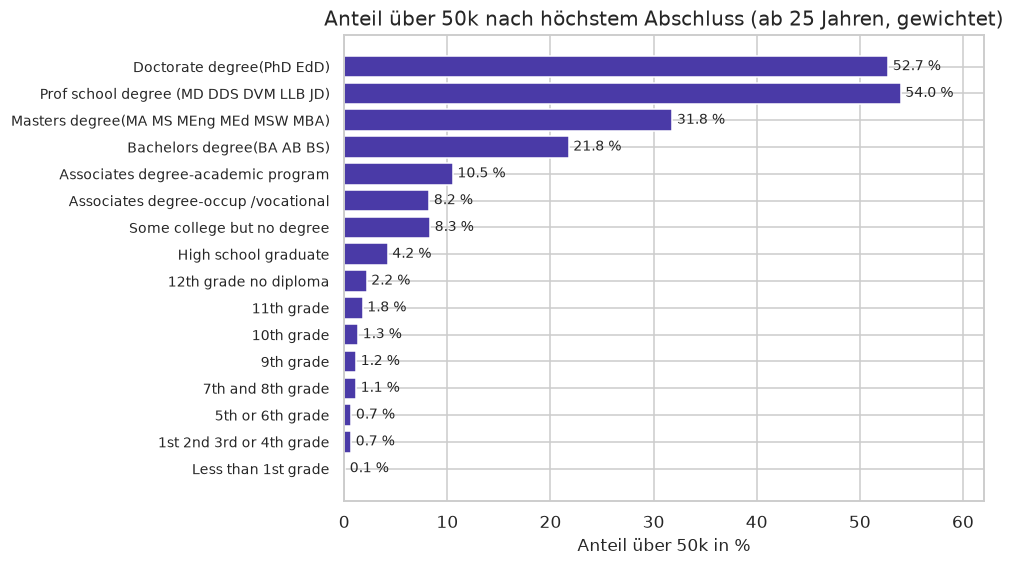

                                            n  anteil_%
EDUCATION                                              
Less than 1st grade                       754       0.1
1st 2nd 3rd or 4th grade                 1727       0.7
5th or 6th grade                         2996       0.7
7th and 8th grade                        6076       1.1
9th grade                                3123       1.2
10th grade                               4343       1.3
11th grade                               3858       1.8
12th grade no diploma                    1314       2.2
High school graduate                    42912       4.2
Some college but no degree              21630       8.3
Associates degree-occup /vocational      4931       8.2
Associates degree-academic program       3997      10.5
Bachelors degree(BA AB BS)              18508      21.8
Masters degree(MA MS MEng MEd MSW MBA)   6487      31.8
Prof school degree (MD DDS DVM LLB JD)   1790      54.0
Doctorate degree(PhD EdD)                1261   

In [12]:
ab25 = daten[daten["AGE"] >= 25]
nach_bildung = anteil_ueber_50k(ab25, "EDUCATION")
print(f"Balken: nur Personen ab 25 Jahren, {len(ab25)} Zeilen.")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
balken = ax.barh(nach_bildung.index.astype(str), nach_bildung["anteil_%"], color=FARBE_UEBER_50K)
ax.bar_label(balken, fmt="%.1f %%", padding=3, fontsize=9)
ax.set_xlim(0, 62)
ax.set_title("Anteil über 50k nach höchstem Abschluss (ab 25 Jahren, gewichtet)")
ax.set_xlabel("Anteil über 50k in %")
ax.tick_params(axis="y", labelsize=9)
plt.show()

print(nach_bildung.round(1))

**Erkenntnis:**
- Der Anteil steigt wie eine **Treppe** mit dem Abschluss. Ohne High-School-Abschluss liegen höchstens 2.2 % über 50k, mit High-School-Abschluss 4.2 %.
- Der grosse Sprung kommt mit dem **Bachelor**: 21.8 %, also rund fünfmal so viel wie mit High School. College ohne Abschluss und die beiden Associate-Abschlüsse liegen dazwischen bei 8 bis 11 %.
- Mit einem Abschluss einer **Professional School** (z.B. Medizin, Jura) oder einem **Doktorat** liegt mehr als die Hälfte über 50k (54.0 % und 52.7 %).
- Bildung erklärt die Schere aus Plot 2 aber nicht automatisch. Dafür müssten wir die Abschlüsse von Frauen und Männern vergleichen, das machen wir hier nicht.

### 1.4 Arbeitszeit: Muss man das ganze Jahr arbeiten?

Wir vergleichen die gearbeiteten Wochen pro Jahr (`WEEKS_WORKED`) zwischen den beiden Einkommensklassen. Weil die Gruppe über 50k viel kleiner ist, zeigen wir pro Gruppe Prozente statt Anzahlen (`common_norm=False`), sonst wäre die violette Linie kaum zu sehen.

Histogramme: Personen ab 15 Jahren, 152101 Zeilen.


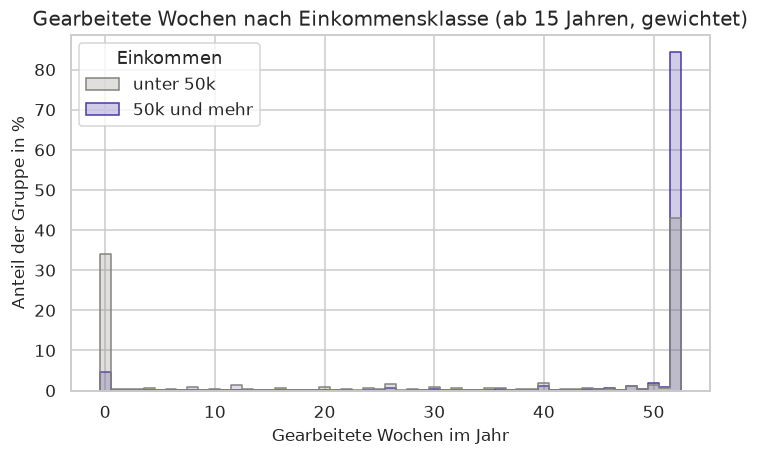

50k und mehr  0 Wochen: 4.7%   52 Wochen: 84.4%
unter 50k     0 Wochen: 34.0%   52 Wochen: 43.0%

Ganzes Jahr gearbeitet (52 Wochen), nach Geschlecht:
Frauen  39.3%
Männer  54.1%


In [13]:
print(f"Histogramme: Personen ab 15 Jahren, {len(ab15)} Zeilen.")

fig, ax = plt.subplots()
sns.histplot(
    data=ab15, x="WEEKS_WORKED", hue="EINKOMMEN", weights="WEIGHT",
    binwidth=1, binrange=(-0.5, 52.5),  # ein Balken pro Woche
    stat="percent", common_norm=False, element="step",
    hue_order=["unter 50k", "50k und mehr"], palette=FARBEN_EINKOMMEN, ax=ax,
)
ax.set_title("Gearbeitete Wochen nach Einkommensklasse (ab 15 Jahren, gewichtet)")
ax.set_xlabel("Gearbeitete Wochen im Jahr")
ax.set_ylabel("Anteil der Gruppe in %")
ax.get_legend().set_title("Einkommen")
plt.show()

for gruppe, d in ab15.groupby("EINKOMMEN"):
    null = np.average(d["WEEKS_WORKED"] == 0, weights=d["WEIGHT"])
    ganz = np.average(d["WEEKS_WORKED"] == 52, weights=d["WEIGHT"])
    print(f"{gruppe:13s} 0 Wochen: {null:.1%}   52 Wochen: {ganz:.1%}")

print("\nGanzes Jahr gearbeitet (52 Wochen), nach Geschlecht:")
for geschlecht, d in ab15.groupby("GESCHLECHT"):
    print(f"{geschlecht:7s} {np.average(d['WEEKS_WORKED'] == 52, weights=d['WEIGHT']):.1%}")

**Erkenntnis:**
- Die Gruppe **unter 50k ist zweigipflig**: rund ein Drittel hat gar nicht gearbeitet (0 Wochen), gut 40 % das ganze Jahr. Nach VL02 deutet das auf eine Mischung aus zwei Gruppen hin, hier Nicht-Erwerbstätige (z.B. Rentner, Schüler, Hausarbeit) und Ganzjahres-Erwerbstätige. Eine einzelne Kennzahl wie der Mittelwert würde keine der beiden Gruppen beschreiben.
- Die Gruppe **über 50k hat praktisch nur einen Gipfel**: 84 % haben 52 Wochen gearbeitet, unter 5 % gar nicht (das sind vermutlich Personen mit Kapital- oder Renteneinkommen).
- Für die Schere aus Plot 2 ist das ein erster Hinweis: Nur 39.3 % der Frauen ab 15 haben das ganze Jahr gearbeitet, bei den Männern 54.1 %. Die gearbeiteten Stunden pro Woche (Teilzeit) enthält der Datensatz leider nicht.

### 1.5 Beruf: Liegt der Unterschied nur an der Berufswahl?

Wenn Frauen einfach häufiger in schlechter bezahlten Berufen arbeiten würden, müsste der Unterschied **innerhalb** eines Berufs verschwinden. Wir rechnen deshalb für jede Berufsgruppe (`MAJOR_OCCUPATION`) den Anteil über 50k getrennt für Frauen und Männer. Jeder Punkt ist eine Berufsgruppe, die Grösse zeigt die Anzahl Personen. Auf der gestrichelten Diagonale wären Frauen und Männer gleich oft über 50k.

Scatterplot: 12 Berufsgruppen, 98023 Personen. Weggelassen (zu klein): ['Armed Forces', 'Private household services']


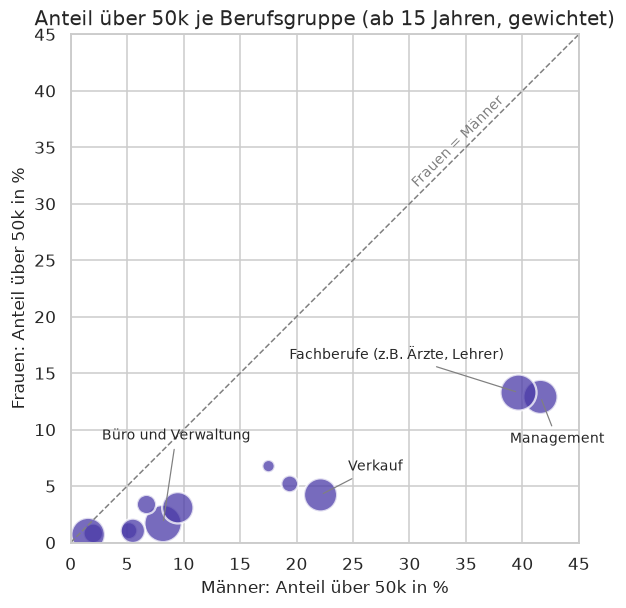

                                       Frauen_%  Männer_%      n
MAJOR_OCCUPATION                                                
Executive admin and managerial             12.9      41.6  12495
Professional specialty                     13.3      39.7  13940
Sales                                       4.2      22.1  11783
Technicians and related support             5.2      19.4   3018
Protective services                         6.8      17.5   1661
Precision production craft & repair         3.1       9.5  10518
Adm support including clerical              1.7       8.2  14837
Transportation and material moving          3.4       6.7   4020
Machine operators assmblrs & inspctrs       1.0       5.5   6379
Farming forestry and fishing                1.1       5.1   3146
Handlers equip cleaners etc                 0.8       2.0   4127
Other service                               0.7       1.5  12099


In [14]:
erwerbstaetige = ab15[ab15["MAJOR_OCCUPATION"] != "Not in universe"]
nach_beruf = anteil_ueber_50k(erwerbstaetige, ["MAJOR_OCCUPATION", "GESCHLECHT"]).unstack()

# Nur Berufsgruppen mit mindestens 100 Frauen und 100 Männern, sonst schwanken die Anteile zu stark
genug = (nach_beruf["n"] >= 100).all(axis=1)
weggelassen = list(nach_beruf.index[~genug])
nach_beruf = nach_beruf[genug]
maenner = nach_beruf["anteil_%"]["Männer"]
frauen = nach_beruf["anteil_%"]["Frauen"]
groesse = nach_beruf["n"].sum(axis=1)
print(f"Scatterplot: {len(nach_beruf)} Berufsgruppen, {groesse.sum()} Personen. Weggelassen (zu klein): {weggelassen}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 45], [0, 45], linestyle="--", color="gray", linewidth=1)
ax.text(30, 31.5, "Frauen = Männer", color="gray", rotation=45, fontsize=9)
ax.scatter(maenner, frauen, s=groesse / 25, color=FARBE_UEBER_50K, alpha=0.75, edgecolor="white", linewidth=1.5)

# Nur die grössten Berufsgruppen beschriften, sonst wird es unlesbar
beschriftung = {
    "Executive admin and managerial": ("Management", (-20, -30)),
    "Professional specialty": ("Fachberufe (z.B. Ärzte, Lehrer)", (-150, 22)),
    "Sales": ("Verkauf", (18, 16)),
    "Adm support including clerical": ("Büro und Verwaltung", (-40, 55)),
}
for beruf, (text, versatz) in beschriftung.items():
    ax.annotate(text, xy=(maenner[beruf], frauen[beruf]), xytext=versatz, textcoords="offset points", fontsize=9,
                arrowprops={"arrowstyle": "-", "color": "gray", "linewidth": 0.8})

ax.set_xlim(0, 45)
ax.set_ylim(0, 45)
ax.set_aspect("equal")
ax.set_title("Anteil über 50k je Berufsgruppe (ab 15 Jahren, gewichtet)")
ax.set_xlabel("Männer: Anteil über 50k in %")
ax.set_ylabel("Frauen: Anteil über 50k in %")
plt.show()

tabelle = pd.DataFrame({"Frauen_%": frauen, "Männer_%": maenner, "n": groesse}).sort_values("Männer_%", ascending=False)
print(tabelle.round(1))

**Erkenntnis:**
- **Alle Punkte liegen deutlich unter der Diagonale.** In keiner der 12 Berufsgruppen erreichen Frauen so oft 50k wie Männer.
- Am grössten ist der Abstand in den gut bezahlten Gruppen: Im **Management** liegen 41.6 % der Männer über 50k, aber nur 12.9 % der Frauen. Bei den **Fachberufen** sind es 39.7 % gegen 13.3 %. Das ist jeweils rund das Dreifache.
- Die Berufswahl erklärt die Schere aus Plot 2 also nicht allein. Die Berufsgruppen sind aber sehr grob (z.B. stecken Chefärztin und Lehrer beide in "Fachberufe"). Ob der Unterschied an der Position, der Arbeitszeit (Plot 4), der Erfahrung oder an ungleicher Bezahlung liegt, können wir mit diesen Daten nicht trennen.

### 1.6 Stundenlohn: Wie ist er verteilt?

Ab hier schauen wir nicht mehr auf die Grenze von 50k, sondern auf den Stundenlohn selbst (`WAGE_PER_HOUR`, seit der Bereinigung in USD). Er ist nur für Personen erfasst, die im Stundenlohn bezahlt werden. Nach VL02 schauen wir zuerst die Form an und wählen dann die Lagekennzahl. Damit einzelne Beträge sichtbar werden, ist jeder Balken nur 25 Cents breit und genau um den Betrag zentriert.

Histogramm: nur Lohnbezieher, 11304 Zeilen. Gezeigt bis 30 USD, 104 Werte liegen darüber.


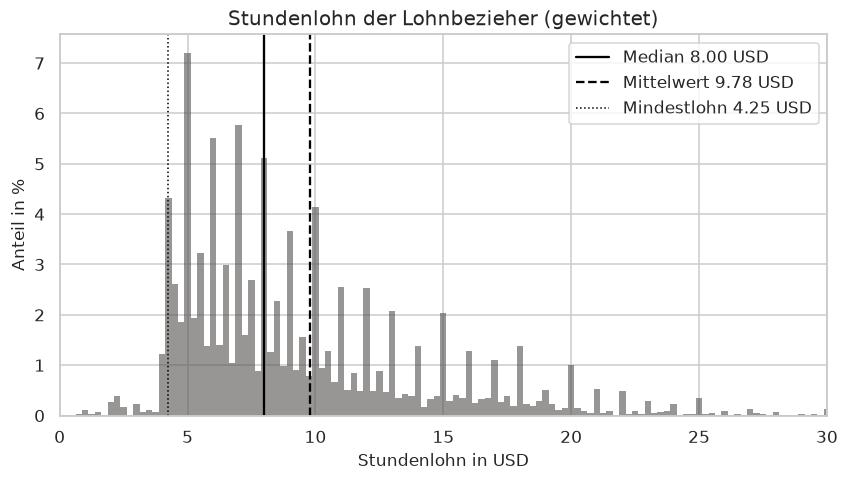

Genau ganze Dollar:      45.6%
Genau Mindestlohn:       3.3%
Unter dem Mindestlohn:   2.8%
Maximum:                 99.99 USD


In [15]:
lohn = daten[daten["WAGE_PER_HOUR"] > 0]
mittelwert = np.average(lohn["WAGE_PER_HOUR"], weights=lohn["WEIGHT"])
median = gewichtetes_quantil(lohn["WAGE_PER_HOUR"], lohn["WEIGHT"], 0.5)
MINDESTLOHN = 4.25  # US-Mindestlohn 1994/95 in USD pro Stunde
print(f"Histogramm: nur Lohnbezieher, {len(lohn)} Zeilen. Gezeigt bis 30 USD, "
      f"{(lohn['WAGE_PER_HOUR'] > 30).sum()} Werte liegen darüber.")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=lohn, x="WAGE_PER_HOUR", weights="WEIGHT", stat="percent",
             binwidth=0.25, binrange=(-0.125, 30.125), color="#52514e", alpha=0.6, linewidth=0, ax=ax)
ax.axvline(median, color="black", linewidth=1.5, label=f"Median {median:.2f} USD")
ax.axvline(mittelwert, color="black", linewidth=1.5, linestyle="--", label=f"Mittelwert {mittelwert:.2f} USD")
ax.axvline(MINDESTLOHN, color="black", linewidth=1, linestyle=":", label=f"Mindestlohn {MINDESTLOHN:.2f} USD")
ax.set_xlim(0, 30)
ax.set_title("Stundenlohn der Lohnbezieher (gewichtet)")
ax.set_xlabel("Stundenlohn in USD")
ax.set_ylabel("Anteil in %")
ax.legend()
plt.show()

ganze_dollar = lohn["WAGE_PER_HOUR"] % 1 == 0
print(f"Genau ganze Dollar:      {np.average(ganze_dollar, weights=lohn['WEIGHT']):.1%}")
print(f"Genau Mindestlohn:       {np.average(lohn['WAGE_PER_HOUR'] == MINDESTLOHN, weights=lohn['WEIGHT']):.1%}")
print(f"Unter dem Mindestlohn:   {np.average(lohn['WAGE_PER_HOUR'] < MINDESTLOHN, weights=lohn['WEIGHT']):.1%}")
print(f"Maximum:                 {lohn['WAGE_PER_HOUR'].max():.2f} USD")

**Erkenntnis:**
- Die Verteilung ist **rechtsschief**: Der Mittelwert (9.78 USD) liegt über dem Median (8.00 USD), weil eine lange Flanke bis knapp 100 USD den Mittelwert nach oben zieht. Für einen typischen Stundenlohn berichten wir deshalb den Median (VL02: "Erst die Form, dann die Kennzahl").
- Das Histogramm sieht aus wie ein **Kamm**: 45.6 % aller Angaben sind genau ganze Dollar, dazwischen sind die Balken viel niedriger. Die Befragten runden ihren Lohn (**Heaping**, eine Form von Messfehler aus VL01).
- Beim gesetzlichen **Mindestlohn** von 4.25 USD steht eine eigene Spitze (3.3 % genau auf diesem Betrag). 2.8 % liegen sogar darunter. Möglich sind Ausnahmen vom Mindestlohn, z.B. Berufe mit Trinkgeld, geprüft haben wir das nicht.

### 1.7 Verdienen Männer auch pro Stunde mehr? Die ECDF

Die ECDF (VL02) zeigt für jeden Lohn, welcher Anteil der Gruppe höchstens so viel verdient. Sie braucht keine Klassenbreite und lässt sich in zwei Richtungen lesen: vom Lohn zum Anteil und vom Anteil (z.B. 50 %) zum Quantil.

ECDF: nur Lohnbezieher, 11304 Zeilen. Gezeigt bis 30 USD.


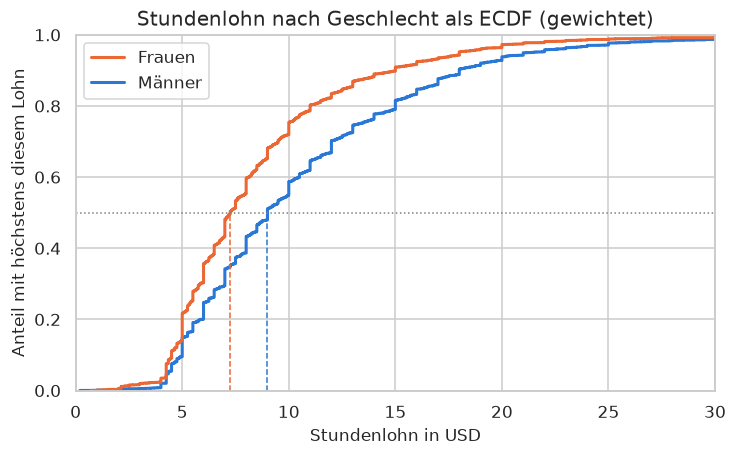

         Frauen  Männer
Q(0.25)    5.45    6.15
Median     7.25    9.00
Q(0.75)   10.00   13.32
Q(0.9)    15.00   18.00

Anteil der Männer mit höchstens 10 USD: 58.6%


In [16]:
print(f"ECDF: nur Lohnbezieher, {len(lohn)} Zeilen. Gezeigt bis 30 USD.")

fig, ax = plt.subplots()
sns.ecdfplot(data=lohn, x="WAGE_PER_HOUR", hue="GESCHLECHT", weights="WEIGHT",
             hue_order=["Frauen", "Männer"], palette=FARBEN_GESCHLECHT, linewidth=2, ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)

# Median je Geschlecht als senkrechte Linie bis zur 50-%-Marke
quantile = {}
for geschlecht, d in lohn.groupby("GESCHLECHT"):
    quantile[geschlecht] = [gewichtetes_quantil(d["WAGE_PER_HOUR"], d["WEIGHT"], p) for p in (0.25, 0.5, 0.75, 0.9)]
    ax.plot([quantile[geschlecht][1]] * 2, [0, 0.5], color=FARBEN_GESCHLECHT[geschlecht], linestyle="--", linewidth=1)

ax.set_xlim(0, 30)
ax.set_title("Stundenlohn nach Geschlecht als ECDF (gewichtet)")
ax.set_xlabel("Stundenlohn in USD")
ax.set_ylabel("Anteil mit höchstens diesem Lohn")
ax.get_legend().set_title(None)
plt.show()

print(pd.DataFrame(quantile, index=["Q(0.25)", "Median", "Q(0.75)", "Q(0.9)"]).round(2))
maenner_lohn = lohn[lohn["GESCHLECHT"] == "Männer"]
print(f"\nAnteil der Männer mit höchstens 10 USD: {np.average(maenner_lohn['WAGE_PER_HOUR'] <= 10, weights=maenner_lohn['WEIGHT']):.1%}")

**Erkenntnis:**
- Die Kurve der Männer liegt **überall rechts** von der Kurve der Frauen. Egal welches Quantil wir nehmen, Männer verdienen pro Stunde mehr: Median 9.00 gegen 7.25 USD, beim 75-%-Quantil 13.32 gegen 10.00 USD.
- Andersherum gelesen: 75 % der Frauen verdienen höchstens 10 USD pro Stunde, bei den Männern sind es nur rund 60 %.
- Die Kurve der Frauen ist steiler. Ihre Löhne liegen also enger beieinander (IQR 4.55 gegen 7.17 USD).
- Der Unterschied aus Plot 2 liegt also nicht nur an der Arbeitszeit (Plot 4), sondern zeigt sich auch beim Lohn pro Stunde. Das gilt aber nur für Personen im Stundenlohn.

### 1.8 Bildung und Stundenlohn: Höhe und Streuung im Boxplot

Plot 3 hat gezeigt, dass Bildung die Chance auf über 50k stark erhöht. Wie sieht das beim Stundenlohn aus? Damit der Boxplot lesbar bleibt, fassen wir die Abschlüsse zu sechs Gruppen zusammen. Wir nehmen wieder Personen ab 25 Jahren. Der Boxplot ist ungewichtet.

Boxplot: Lohnbezieher ab 25 Jahren, 8915 Zeilen. Gezeigt bis 40 USD, 47 Werte liegen darüber.


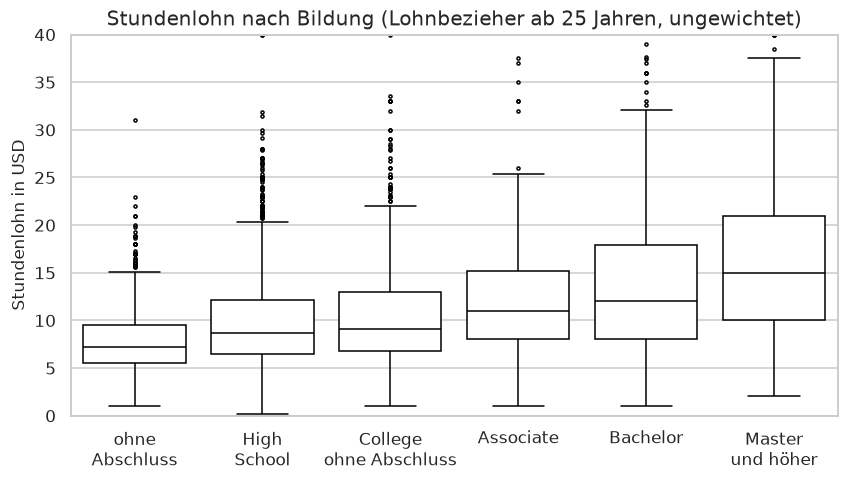

                         count    25%    50%    75%    IQR
BILDUNGSGRUPPE                                            
ohne Abschluss          1152.0   5.49   7.20   9.50   4.01
High School             3773.0   6.50   8.65  12.15   5.65
College ohne Abschluss  1914.0   6.76   9.05  13.00   6.24
Associate                860.0   8.00  11.00  15.18   7.18
Bachelor                 956.0   8.09  12.00  17.88   9.79
Master und höher         260.0  10.00  15.00  21.00  11.00


In [17]:
BILDUNGSGRUPPEN = {
    "High school graduate": "High School",
    "Some college but no degree": "College ohne Abschluss",
    "Associates degree-occup /vocational": "Associate",
    "Associates degree-academic program": "Associate",
    "Bachelors degree(BA AB BS)": "Bachelor",
    "Masters degree(MA MS MEng MEd MSW MBA)": "Master und höher",
    "Prof school degree (MD DDS DVM LLB JD)": "Master und höher",
    "Doctorate degree(PhD EdD)": "Master und höher",
}
REIHENFOLGE = ["ohne Abschluss", "High School", "College ohne Abschluss", "Associate", "Bachelor", "Master und höher"]

lohn25 = lohn[lohn["AGE"] >= 25].copy()
# Alle Stufen unter High School gelten als "ohne Abschluss"
lohn25["BILDUNGSGRUPPE"] = lohn25["EDUCATION"].astype(str).map(BILDUNGSGRUPPEN).fillna("ohne Abschluss")
print(f"Boxplot: Lohnbezieher ab 25 Jahren, {len(lohn25)} Zeilen. Gezeigt bis 40 USD, "
      f"{(lohn25['WAGE_PER_HOUR'] > 40).sum()} Werte liegen darüber.")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=lohn25, x="BILDUNGSGRUPPE", y="WAGE_PER_HOUR", order=REIHENFOLGE,
            color="white", linecolor="black", fliersize=2, ax=ax)
ax.set_ylim(0, 40)
ax.set_title("Stundenlohn nach Bildung (Lohnbezieher ab 25 Jahren, ungewichtet)")
ax.set_xticks(range(len(REIHENFOLGE)), [g.replace(" ", "\n", 1) for g in REIHENFOLGE])  # Zeilenumbruch, sonst überlappen die Namen
ax.set_xlabel(None)
ax.set_ylabel("Stundenlohn in USD")
plt.show()

kennzahlen = lohn25.groupby("BILDUNGSGRUPPE")["WAGE_PER_HOUR"].describe().loc[REIHENFOLGE]
kennzahlen["IQR"] = kennzahlen["75%"] - kennzahlen["25%"]
print(kennzahlen[["count", "25%", "50%", "75%", "IQR"]].round(2))

**Erkenntnis:**
- Der **Median steigt** mit jeder Bildungsstufe: von 7.20 USD ohne Abschluss über 8.65 USD mit High School bis 15.00 USD mit Master oder höher.
- Gleichzeitig wird die **Box breiter**: Der IQR wächst von rund 4 USD auf 11 USD. Mehr Bildung hebt also nicht nur das Niveau, die Löhne gehen auch weiter auseinander.
- In jeder Gruppe gibt es viele Punkte über dem oberen Whisker. Das sind keine Fehler, sondern die lange rechte Flanke aus Plot 6.
- Vorsicht bei der Gruppe "Master und höher": Nur 260 Personen. Akademiker werden selten im Stundenlohn bezahlt, die Gruppe ist also nicht typisch für alle Akademiker.

### 1.9 Verdienen Gewerkschaftsmitglieder mehr? Der Stripplot

Ein Boxplot fasst die Werte zusammen, ein Stripplot zeigt jeden einzelnen Punkt (leicht gestreut, damit sie sich nicht überdecken). Damit das Bild lesbar bleibt, ziehen wir pro Gruppe zufällig 300 Personen (mit unserem Seed). Die schwarzen Striche sind die Mediane aller Personen der Gruppe. Der Plot ist ungewichtet.

Stripplot: je 300 von 11304 Lohnbeziehern pro Gruppe. Gezeigt bis 35 USD.


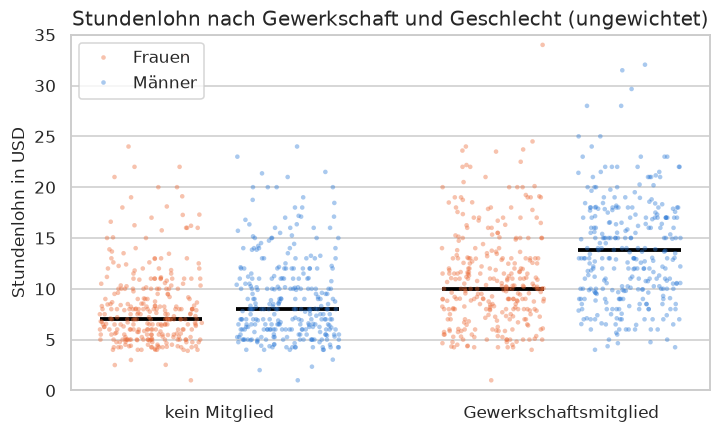

Median Stundenlohn in USD (alle Lohnbezieher):
GESCHLECHT          Frauen  Männer
LABOR_UNION_MEMBER                
No                     7.0    8.00
Yes                   10.0   13.82

Anzahl Personen:
GESCHLECHT          Frauen  Männer
LABOR_UNION_MEMBER                
No                    5196    4134
Yes                    662    1312

Median-Alter und Männeranteil nach Mitgliedschaft:
                    median_alter  maenneranteil
LABOR_UNION_MEMBER                             
No                          34.0           0.44
Yes                         41.0           0.66


In [18]:
lohn_gruppen = lohn.groupby(["LABOR_UNION_MEMBER", "GESCHLECHT"])
stichprobe = lohn_gruppen.sample(n=300, random_state=SEED)
print(f"Stripplot: je 300 von {len(lohn)} Lohnbeziehern pro Gruppe. Gezeigt bis 35 USD.")

fig, ax = plt.subplots()
sns.stripplot(data=stichprobe, x="LABOR_UNION_MEMBER", y="WAGE_PER_HOUR", hue="GESCHLECHT",
              order=["No", "Yes"], hue_order=["Frauen", "Männer"], palette=FARBEN_GESCHLECHT,
              dodge=True, jitter=0.3, size=3, alpha=0.4, ax=ax)

# Median je Gruppe (alle Personen, nicht nur die Stichprobe) als schwarzer Strich
mediane = lohn_gruppen["WAGE_PER_HOUR"].median()
for x, mitglied in enumerate(["No", "Yes"]):
    for versatz, geschlecht in [(-0.2, "Frauen"), (0.2, "Männer")]:
        ax.hlines(mediane[(mitglied, geschlecht)], x + versatz - 0.15, x + versatz + 0.15, color="black", linewidth=2.5)

ax.set_ylim(0, 35)
ax.set_xticks([0, 1], ["kein Mitglied", "Gewerkschaftsmitglied"])
ax.set_title("Stundenlohn nach Gewerkschaft und Geschlecht (ungewichtet)")
ax.set_xlabel(None)
ax.set_ylabel("Stundenlohn in USD")
ax.legend(loc="upper left")
plt.show()

print("Median Stundenlohn in USD (alle Lohnbezieher):")
print(mediane.unstack().round(2))
print("\nAnzahl Personen:")
print(lohn_gruppen.size().unstack())
print("\nMedian-Alter und Männeranteil nach Mitgliedschaft:")
print(lohn.groupby("LABOR_UNION_MEMBER").agg(median_alter=("AGE", "median"),
                                             maenneranteil=("GESCHLECHT", lambda s: (s == "Männer").mean().round(2))))

**Erkenntnis:**
- Gewerkschaftsmitglieder verdienen im Median deutlich mehr, und zwar **bei Frauen und Männern**: Frauen 10.00 statt 7.00 USD, Männer 13.82 statt 8.00 USD.
- Der Stripplot zeigt auch, wie unterschiedlich die Gruppen sind: Bei den Nicht-Mitgliedern liegen viele Punkte dicht beim Mindestlohn, bei den Mitgliedern deutlich weniger (höchstens 5 USD: 21.4 % gegen 3.6 %).
- Das heisst aber noch nicht, dass die Mitgliedschaft den Lohn erhöht. Die Mitglieder sind im Median älter (41 gegen 34 Jahre) und öfter Männer (66 % gegen 44 %), und sie arbeiten doppelt so oft im Handwerk (21 % gegen 11 %). Ein Teil des Unterschieds kommt also von der **Zusammensetzung** der Gruppen. Trennen können wir das erst mit Regression (VL10 und VL11).

### 1.10 Und das Vermögen? Dividenden als Heavy Tail

Zum Schluss das Kapitaleinkommen: Dividenden aus Aktien (`DIVIDENDS`). In NB01 (Abschnitt 4.3) haben wir gesehen, dass man sie nur auf einer logarithmischen Skala sinnvoll darstellen kann. Hier vergleichen wir die beiden Einkommensklassen, nur Personen ab 15 Jahren mit Dividenden über 0.

Histogramm: Personen ab 15 Jahren mit Dividenden > 0, 21141 von 152101 Zeilen.


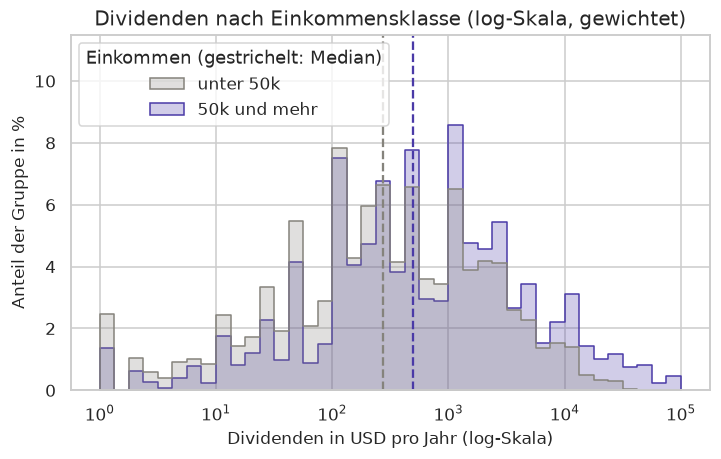

50k und mehr  mit Dividenden: 42.8%   Median: 500 USD
unter 50k     mit Dividenden: 11.2%   Median: 275 USD

Alle mit Dividenden: Mittelwert 1851 USD, Median 320 USD
Die obersten 10 % (ab 4146 USD) erhalten 68.0% aller Dividenden.


In [19]:
mit_dividenden = ab15[ab15["DIVIDENDS"] > 0]
print(f"Histogramm: Personen ab 15 Jahren mit Dividenden > 0, {len(mit_dividenden)} von {len(ab15)} Zeilen.")

fig, ax = plt.subplots()
sns.histplot(data=mit_dividenden, x="DIVIDENDS", hue="EINKOMMEN", weights="WEIGHT",
             log_scale=True, bins=40, stat="percent", common_norm=False, element="step",
             hue_order=["unter 50k", "50k und mehr"], palette=FARBEN_EINKOMMEN, ax=ax)

# Median je Einkommensklasse
for gruppe, d in mit_dividenden.groupby("EINKOMMEN"):
    ax.axvline(gewichtetes_quantil(d["DIVIDENDS"], d["WEIGHT"], 0.5), color=FARBEN_EINKOMMEN[gruppe], linestyle="--", linewidth=1.5)

ax.set_title("Dividenden nach Einkommensklasse (log-Skala, gewichtet)")
ax.set_xlabel("Dividenden in USD pro Jahr (log-Skala)")
ax.set_ylabel("Anteil der Gruppe in %")
ax.set_ylim(0, 11.5)  # Platz für die Legende
sns.move_legend(ax, "upper left", title="Einkommen (gestrichelt: Median)")
plt.show()

for gruppe, d in ab15.groupby("EINKOMMEN"):
    hat = d[d["DIVIDENDS"] > 0]
    print(f"{gruppe:13s} mit Dividenden: {np.average(d['DIVIDENDS'] > 0, weights=d['WEIGHT']):.1%}   "
          f"Median: {gewichtetes_quantil(hat['DIVIDENDS'], hat['WEIGHT'], 0.5):.0f} USD")

# Wie stark sind die Dividenden konzentriert?
betrag = mit_dividenden["DIVIDENDS"] * mit_dividenden["WEIGHT"]
grenze = gewichtetes_quantil(mit_dividenden["DIVIDENDS"], mit_dividenden["WEIGHT"], 0.9)
print(f"\nAlle mit Dividenden: Mittelwert {np.average(mit_dividenden['DIVIDENDS'], weights=mit_dividenden['WEIGHT']):.0f} USD, "
      f"Median {gewichtetes_quantil(mit_dividenden['DIVIDENDS'], mit_dividenden['WEIGHT'], 0.5):.0f} USD")
print(f"Die obersten 10 % (ab {grenze:.0f} USD) erhalten {betrag[mit_dividenden['DIVIDENDS'] >= grenze].sum() / betrag.sum():.1%} aller Dividenden.")

**Erkenntnis:**
- Personen über 50k haben fast **viermal so oft** Dividenden wie Personen darunter (42.8 % gegen 11.2 %), und wenn, dann im Median fast doppelt so viel (500 gegen 275 USD). Hohes Einkommen und Vermögen hängen also zusammen.
- Die Dividenden haben einen **Heavy Tail** (VL02): Der Mittelwert liegt ein Vielfaches über dem Median, und die obersten 10 % erhalten rund zwei Drittel aller Dividenden. Die grossen Werte sind keine Ausreisser, sondern gehören zur Verteilung.
- Auf der log-Skala sehen beide Verteilungen fast symmetrisch aus. Auch hier gibt es Heaping bei runden Beträgen (z.B. 100, 500, 1'000 USD), das erklärt die Zacken.

### Die Geschichte in fünf Sätzen

Für die Präsentation lässt sich der Abschnitt so zusammenfassen:

1. **Nur eine kleine Gruppe verdient über 50k.** Ab 15 Jahren sind es rund 8 %, und fast alle von ihnen arbeiten das ganze Jahr (Plots 2 und 4).
2. **Bildung ist die grösste Stufe.** Mit Bachelor liegt der Anteil fünfmal so hoch wie mit High School, mit Professional School oder Doktorat bei über 50 % (Plots 3 und 8).
3. **Zwischen Frauen und Männern öffnet sich ab 30 eine Schere.** Mit 50 liegen Männer viermal so oft über 50k, und zwar in jeder Berufsgruppe und auch beim Lohn pro Stunde (Plots 2, 5 und 7).
4. **Löhne sind rechtsschief und gerundet.** Der Median ist die bessere Kennzahl, und viele Angaben sind ganze Dollar oder genau der Mindestlohn (Plot 6).
5. **Vermögen ist noch ungleicher verteilt als Lohn.** Die obersten 10 % der Dividendenbezieher erhalten rund zwei Drittel aller Dividenden (Plot 10).

Alle Aussagen sind beschreibend. Ob z.B. die Gewerkschaft (Plot 9) oder das Geschlecht den Lohn wirklich beeinflussen, können wir erst mit den Methoden aus den späteren Vorlesungen prüfen.